In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
xgb_model = joblib.load("../models/xgboost.pkl")
print("XGBoost model loaded successfully!")

XGBoost model loaded successfully!


In [3]:
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
X_test = X_test.reset_index(drop=True)
print("X_test shape:", X_test.shape)

X_test shape: (1409, 45)


In [4]:
y_test = pd.read_csv("../data/processed/y_test.csv")
y_test = y_test.squeeze().reset_index(drop=True)
print("y_test shape:", y_test.shape)

y_test shape: (1409,)


In [5]:
explainer = shap.TreeExplainer(xgb_model)
print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [6]:
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 45)


In [7]:
customer_index = 0
customer = X_test.iloc[[customer_index]]

print("Selected customer index:", customer_index)
print("Customer shape:", customer.shape)

Selected customer index: 0
Customer shape: (1, 45)


In [8]:
churn_probability = xgb_model.predict_proba(customer)[0][1]

print(f"Predicted churn probability: {churn_probability:.2%}")

Predicted churn probability: 1.75%


In [9]:
if churn_probability < 0.40:
    risk_level = "Low"
elif churn_probability < 0.70:
    risk_level = "Medium"
else:
    risk_level = "High"

print("Risk level:", risk_level)

Risk level: Low


In [10]:
customer_shap_values = shap_values[customer_index]

print(
    "Number of feature contributions:",
    len(customer_shap_values)
)

Number of feature contributions: 45


In [11]:
customer_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Value": customer_shap_values,
    "Feature_Value": X_test.iloc[customer_index].values
})

customer_explanation["Absolute_SHAP"] = (
    customer_explanation["SHAP_Value"].abs()
)

customer_explanation = customer_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

customer_explanation.head(10)

,Feature,SHAP_Value,Feature_Value,Absolute_SHAP
1,num__tenure,-1.341339,1.608483,1.341339
36,cat__Contract_Month-to-month,-1.024862,0.000000,1.024862
18,cat__OnlineSecurity_No,-0.483551,0.000000,0.483551
8,cat__Dependents_No,-0.370791,0.000000,0.370791
38,cat__Contract_Two year,-0.368173,1.000000,0.368173
27,cat__TechSupport_No,-0.266416,0.000000,0.266416
2,num__MonthlyCharges,0.222559,1.629976,0.222559
43,cat__PaymentMethod_Electronic check,-0.193320,0.000000,0.193320
37,cat__Contract_One year,-0.180458,0.000000,0.180458
21,cat__OnlineBackup_No,-0.175514,0.000000,0.175514


In [12]:
risk_increasing = customer_explanation[
    customer_explanation["SHAP_Value"] > 0
].copy()

risk_reducing = customer_explanation[
    customer_explanation["SHAP_Value"] < 0
].copy()

print("Risk-increasing factors:", len(risk_increasing))
print("Risk-reducing factors:", len(risk_reducing))

Risk-increasing factors: 15
Risk-reducing factors: 22


In [13]:
top_risk_factors = risk_increasing.sort_values(
    "SHAP_Value",
    ascending=False
).head(5)

top_risk_factors[
    ["Feature", "SHAP_Value", "Feature_Value"]
]

,Feature,SHAP_Value,Feature_Value
2,num__MonthlyCharges,0.222559,1.629976
16,cat__InternetService_Fiber optic,0.142042,1.000000
35,cat__StreamingMovies_Yes,0.132224,1.000000
32,cat__StreamingTV_Yes,0.083029,1.000000
12,cat__MultipleLines_No,0.055103,0.000000


In [14]:
top_protective_factors = risk_reducing.sort_values(
    "SHAP_Value",
    ascending=True
).head(5)

top_protective_factors[
    ["Feature", "SHAP_Value", "Feature_Value"]
]

,Feature,SHAP_Value,Feature_Value
1,num__tenure,-1.341339,1.608483
36,cat__Contract_Month-to-month,-1.024862,0.000000
18,cat__OnlineSecurity_No,-0.483551,0.000000
8,cat__Dependents_No,-0.370791,0.000000
38,cat__Contract_Two year,-0.368173,1.000000


In [15]:
customer_summary = {
    "Customer_Index": customer_index,
    "Churn_Probability": churn_probability,
    "Risk_Level": risk_level,
    "Top_Risk_Factor_1": (
        top_risk_factors.iloc[0]["Feature"]
        if len(top_risk_factors) > 0 else None
    ),
    "Top_Risk_Factor_2": (
        top_risk_factors.iloc[1]["Feature"]
        if len(top_risk_factors) > 1 else None
    ),
    "Top_Risk_Factor_3": (
        top_risk_factors.iloc[2]["Feature"]
        if len(top_risk_factors) > 2 else None
    )
}

customer_summary

{'Customer_Index': 0,
 'Churn_Probability': np.float32(0.017471986),
 'Risk_Level': 'Low',
 'Top_Risk_Factor_1': 'num__MonthlyCharges',
 'Top_Risk_Factor_2': 'cat__InternetService_Fiber optic',
 'Top_Risk_Factor_3': 'cat__StreamingMovies_Yes'}

In [16]:
customer_explanation.to_csv(
    "../reports/individual_customer_explanation.csv",
    index=False
)

print("Individual customer explanation saved successfully!")

Individual customer explanation saved successfully!


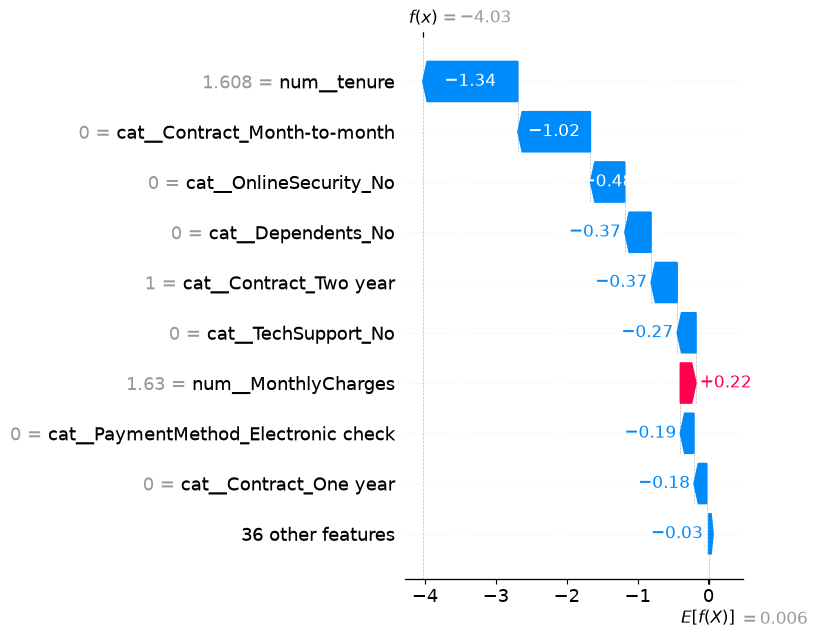

In [17]:
plt.figure(figsize=(10, 7))

shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap_values,
        base_values=explainer.expected_value,
        data=customer.values[0],
        feature_names=X_test.columns
    ),
    max_display=10,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/shap_single_customer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
print("=" * 50)
print("CHURNGUARD - CUSTOMER RISK EXPLANATION")
print("=" * 50)

print(f"Customer Index       : {customer_index}")
print(f"Churn Probability    : {churn_probability:.2%}")
print(f"Risk Level           : {risk_level}")

print("\nTop Factors Increasing Churn Risk:")

for _, row in top_risk_factors.iterrows():
    print(
        f"  + {row['Feature']} "
        f"(SHAP: {row['SHAP_Value']:.3f})"
    )

print("\nTop Factors Reducing Churn Risk:")

for _, row in top_protective_factors.iterrows():
    print(
        f"  - {row['Feature']} "
        f"(SHAP: {row['SHAP_Value']:.3f})"
    )

print("=" * 50)

CHURNGUARD - CUSTOMER RISK EXPLANATION
Customer Index       : 0
Churn Probability    : 1.75%
Risk Level           : Low

Top Factors Increasing Churn Risk:
  + num__MonthlyCharges (SHAP: 0.223)
  + cat__InternetService_Fiber optic (SHAP: 0.142)
  + cat__StreamingMovies_Yes (SHAP: 0.132)
  + cat__StreamingTV_Yes (SHAP: 0.083)
  + cat__MultipleLines_No (SHAP: 0.055)

Top Factors Reducing Churn Risk:
  - num__tenure (SHAP: -1.341)
  - cat__Contract_Month-to-month (SHAP: -1.025)
  - cat__OnlineSecurity_No (SHAP: -0.484)
  - cat__Dependents_No (SHAP: -0.371)
  - cat__Contract_Two year (SHAP: -0.368)


In [19]:
import os

files_to_check = [
    "../reports/individual_customer_explanation.csv",
    "../reports/figures/shap_single_customer.png"
]

for file in files_to_check:
    print(file, "→", os.path.exists(file))

../reports/individual_customer_explanation.csv → True
../reports/figures/shap_single_customer.png → True


In [20]:
def make_readable_feature_name(feature):
    """
    Convert processed feature names into human-readable names.
    """

    if feature.startswith("num__"):
        return feature.replace("num__", "")

    if feature.startswith("cat__"):
        feature = feature.replace("cat__", "")

        # Convert encoded categorical features
        if "_" in feature:
            column, value = feature.split("_", 1)
            return f"{column}: {value}"

        return feature

    return feature

In [21]:
test_features = [
    "num__tenure",
    "num__MonthlyCharges",
    "cat__Contract_Month-to-month",
    "cat__OnlineSecurity_No",
    "cat__InternetService_Fiber optic"
]

for feature in test_features:
    print(
        feature,
        "→",
        make_readable_feature_name(feature)
    )

num__tenure → tenure
num__MonthlyCharges → MonthlyCharges
cat__Contract_Month-to-month → Contract: Month-to-month
cat__OnlineSecurity_No → OnlineSecurity: No
cat__InternetService_Fiber optic → InternetService: Fiber optic


In [22]:
customer_explanation["Readable_Feature"] = (
    customer_explanation["Feature"].apply(
        make_readable_feature_name
    )
)

customer_explanation[
    [
        "Readable_Feature",
        "SHAP_Value",
        "Feature_Value"
    ]
].head(10)

,Readable_Feature,SHAP_Value,Feature_Value
1,tenure,-1.341339,1.608483
36,Contract: Month-to-month,-1.024862,0.000000
18,OnlineSecurity: No,-0.483551,0.000000
8,Dependents: No,-0.370791,0.000000
38,Contract: Two year,-0.368173,1.000000
27,TechSupport: No,-0.266416,0.000000
2,MonthlyCharges,0.222559,1.629976
43,PaymentMethod: Electronic check,-0.193320,0.000000
37,Contract: One year,-0.180458,0.000000
21,OnlineBackup: No,-0.175514,0.000000


In [23]:
top_risk_factors_readable = top_risk_factors.copy()

top_risk_factors_readable["Readable_Feature"] = (
    top_risk_factors_readable["Feature"].apply(
        make_readable_feature_name
    )
)

top_risk_factors_readable[
    [
        "Readable_Feature",
        "SHAP_Value",
        "Feature_Value"
    ]
]

,Readable_Feature,SHAP_Value,Feature_Value
2,MonthlyCharges,0.222559,1.629976
16,InternetService: Fiber optic,0.142042,1.000000
35,StreamingMovies: Yes,0.132224,1.000000
32,StreamingTV: Yes,0.083029,1.000000
12,MultipleLines: No,0.055103,0.000000


In [24]:
top_protective_factors_readable = top_protective_factors.copy()

top_protective_factors_readable["Readable_Feature"] = (
    top_protective_factors_readable["Feature"].apply(
        make_readable_feature_name
    )
)

top_protective_factors_readable[
    [
        "Readable_Feature",
        "SHAP_Value",
        "Feature_Value"
    ]
]

,Readable_Feature,SHAP_Value,Feature_Value
1,tenure,-1.341339,1.608483
36,Contract: Month-to-month,-1.024862,0.000000
18,OnlineSecurity: No,-0.483551,0.000000
8,Dependents: No,-0.370791,0.000000
38,Contract: Two year,-0.368173,1.000000


In [25]:
customer_report = pd.DataFrame({
    "Customer_Index": [customer_index],
    "Churn_Probability": [churn_probability],
    "Risk_Level": [risk_level],
    "Top_Risk_Factors": [
        ", ".join(
            top_risk_factors_readable["Readable_Feature"].tolist()
        )
    ],
    "Top_Protective_Factors": [
        ", ".join(
            top_protective_factors_readable["Readable_Feature"].tolist()
        )
    ]
})

customer_report

,Customer_Index,Churn_Probability,Risk_Level,Top_Risk_Factors,Top_Protective_Factors
0,0,0.017472,Low,"MonthlyCharges, InternetService: Fiber optic, ...","tenure, Contract: Month-to-month, OnlineSecuri..."


In [26]:
customer_report.to_csv(
    "../reports/customer_risk_summary.csv",
    index=False
)

print("Customer risk summary saved successfully!")

Customer risk summary saved successfully!
